# Federated Stroke Pathology Analysis

This notebook is a reproducible, backend-approved federated analysis of stroke pathology data. It first discovers the available platform resources, then defines a clinically meaningful ischemic stroke question using only verified data model variables and MIP `Pipeline` procedures.

No raw patient-level records are requested. All summaries, plots, tests, and models use aggregate or fitted outputs returned by the configured MIP backend.

In [40]:
import inspect
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

import mip
from mip.filters import F
from mip.preprocessing import (
    CategoricalColumnCreator,
    MissingValuesHandler,
    OutlierWinsorizer,
)

pd.set_option("display.max_colwidth", 120)
ALPHA = 0.05

## 1. Discover available platform resources

The first step is to ask the configured MIP backend what resources exist. The analysis below does not assume a data resource, dataset, variable, preprocessing step, or statistical method before checking the client/catalog objects.

In [41]:
client = mip.Client.from_env()
catalog = client.catalog()

catalog_df = pd.DataFrame(catalog.summaries())
display(Markdown("### Data models exposed by the platform"))
display(catalog_df)

stroke_available = (
    (catalog_df["code"] == "Stroke")
    & (catalog_df["version"].astype(str) == "3.7")
).any()
if not stroke_available:
    raise RuntimeError("Stroke data model version 3.7 is not available in this backend catalog.")

dm = catalog.data_model("Stroke", version="3.7")
datasets_df = pd.DataFrame(dm.list_datasets())
display(Markdown("### Datasets in Stroke 3.7"))
display(datasets_df)

if "SSR" not in set(datasets_df["code"]):
    raise RuntimeError("Dataset SSR is not available in Stroke 3.7.")
ssr = dm.datasets["SSR"]

display(Markdown("### Stroke data model tree"))
print(dm.tree())

### Data models exposed by the platform

,code,version,label,longitudinal,n_variables,n_datasets
0,Stroke,3.7,Stroke 3.7,False,197,3
1,tbi,v9,Traumatic Brain Injury,None,771,2


### Datasets in Stroke 3.7

,code,label,n_variables
0,SSR,SSR,197
1,SSR-even,SSR-even,197
2,SSR-odd,SSR-odd,197


### Stroke data model tree

Metadata tree for Stroke:3.7 (Stroke 3.7)
|-- longitudinal: False
|-- datasets (3)
|  |-- SSR
|  |-- SSR-even
|  `-- SSR-odd
|-- groups (15)
|  |-- Acute treatment [0 vars, 2 groups]
|  |  |-- Detailed acute treatment information [0 vars, 1 groups]
|  |  |  `-- Ischemic stroke acute treatment [0 vars, 2 groups]
|  |  |     |-- Ischemic acute endovascular treatment (EVT) [12 vars]
|  |  |     `-- Ischemic acute intravenous treatment (IVT) [3 vars]
|  |  `-- Main acute treatment information [0 vars, 1 groups]
|  |     `-- Ischemic stroke acute treatment [0 vars, 3 groups]
|  |        |-- Ischemic acute conservative treatment [2 vars]
|  |        |-- Ischemic acute endovascular treatment (EVT) [2 vars]
|  |        `-- Ischemic acute intravenous treatment (IVT) [2 vars]
|  |-- Admission imaging [0 vars, 2 groups]
|  |  |-- Detailed admission imaging information [0 vars, 1 groups]
|  |  |  `-- Arterial [0 vars, 2 groups]
|  |  |     |-- Arterial imaging details [1 vars]
|  |  |     `-- Arte

In [42]:
candidate_terms = [
    "age",
    "sex",
    "nihss",
    "mrs",
    "good",
    "death",
    "event",
    "clinical",
    "syndrome",
    "ivt",
    "evt",
    "toast",
    "aca",
    "mca",
    "pca",
    "vba",
    "ich",
    "imaging",
]

candidate_rows = []
for term in candidate_terms:
    for variable in list(dm.variables.search(term))[:20]:
        summary = variable.summary()
        candidate_rows.append(
            {
                "search_term": term,
                "code": summary.get("code"),
                "label": summary.get("label"),
                "type": summary.get("type"),
                "categorical": summary.get("categorical"),
                "numerical": summary.get("numerical"),
            }
        )

candidate_variables_df = (
    pd.DataFrame(candidate_rows)
    .drop_duplicates(["search_term", "code"])
    .sort_values(["search_term", "code"])
    .reset_index(drop=True)
)

display(Markdown("### Candidate stroke variables found by metadata search"))
display(candidate_variables_df)

pipeline_methods = [name for name in dir(mip.Pipeline) if not name.startswith("_")]
method_purpose = {
    "describe": "Aggregate variable summaries and missingness",
    "histogram": "Aggregate histogram or categorical counts",
    "t_test": "Independent two-group comparison for numerical variables",
    "chi_square_test": "Association test for categorical variables",
    "pearson_correlation": "Linear association between numerical variables",
    "logistic_regression": "Binary outcome regression model",
    "summary": "Pipeline metadata summary",
    "explain": "Pipeline analysis set, filters, and preprocessing plan",
}
capabilities_df = pd.DataFrame(
    {
        "pipeline_method": pipeline_methods,
        "purpose": [method_purpose.get(method, "Client method") for method in pipeline_methods],
    }
)

preprocessing_capabilities_df = pd.DataFrame(
    {
        "preprocessing_class": [
            "CategoricalColumnCreator",
            "MissingValuesHandler",
            "OutlierWinsorizer",
        ],
        "purpose": [
            "Create backend-derived categorical variables from filter rules",
            "Apply backend-supported missing-value strategies",
            "Apply backend-supported winsorization for numeric outliers",
        ],
    }
)

display(Markdown("### Available MIP Pipeline methods"))
display(capabilities_df)
display(Markdown("### Available preprocessing capabilities used in this notebook"))
display(preprocessing_capabilities_df)

### Candidate stroke variables found by metadata search

,search_term,code,label,type,categorical,numerical
0,aca,isch_local_aca,ACA,nominal,True,False
1,aca,isch_local_aca_side,ACA Side,nominal,True,False
2,age,age,Age,integer,False,True
3,age,firstimg_native_imagetype,Native imaging setting,nominal,True,False
4,age,fu_imag_result_hemorr,Intracranial hemorhage,nominal,True,False
...,...,...,...,...,...,...
86,toast,toast_unkcmp,Unknown etiology despite complete evaluation,nominal,True,False
87,toast,toast_unkinc,Unknown etiology with incomplete evaluation,nominal,True,False
88,toast,toast_unknown,Toast Unknown,nominal,True,False
89,vba,isch_local_vba,VBA,nominal,True,False


### Available MIP Pipeline methods

,pipeline_method,purpose
0,chi_square_test,Association test for categorical variables
1,describe,Aggregate variable summaries and missingness
2,explain,"Pipeline analysis set, filters, and preprocessing plan"
3,histogram,Aggregate histogram or categorical counts
4,logistic_regression,Binary outcome regression model
5,pearson_correlation,Linear association between numerical variables
6,summary,Pipeline metadata summary
7,t_test,Independent two-group comparison for numerical variables


### Available preprocessing capabilities used in this notebook

,preprocessing_class,purpose
0,CategoricalColumnCreator,Create backend-derived categorical variables from filter rules
1,MissingValuesHandler,Apply backend-supported missing-value strategies
2,OutlierWinsorizer,Apply backend-supported winsorization for numeric outliers


## 2. Clinically meaningful analysis question

Based on the discovered Stroke 3.7 metadata, this notebook studies ischemic stroke records in `SSR` with a classified clinical syndrome.

**Primary question:** Among ischemic stroke patients with total or partial anterior circulation syndrome (`clinical_sdr` TACS/PACS) or posterior circulation syndrome (`clinical_sdr` POCS), are anterior circulation syndrome (`ACS`) and posterior circulation syndrome (`PCS`) associated with age, early neurological severity, acute reperfusion treatment, and good 3-month functional outcome?

**Adjusted question:** After adjusting for age, sex, admission NIHSS, 24-hour NIHSS, IVT, and EVT, is `PCS` associated with the odds of good 3-month mRS outcome compared with `ACS`?

This is an association analysis. The notebook does not claim causation, treatment effectiveness, or mechanistic stroke biology.

In [43]:
required_variable_codes = [
    "age",
    "nihss_24h",
    "nihss_adm_score",
    "biol_sex",
    "acute_treat_ivt",
    "acute_treat_evt",
    "clinical_sdr",
    "event_type",
    "fu_3m_mrs_good",
]

selected_by_code = {}
missing_codes = []
for code in required_variable_codes:
    try:
        selected_by_code[code] = dm.variables[code]
    except Exception:
        missing_codes.append(code)

if missing_codes:
    raise RuntimeError(f"Required variables are missing from Stroke 3.7: {missing_codes}")

age = selected_by_code["age"]
nihss_24h = selected_by_code["nihss_24h"]
nihss_adm = selected_by_code["nihss_adm_score"]
sex = selected_by_code["biol_sex"]
ivt = selected_by_code["acute_treat_ivt"]
evt = selected_by_code["acute_treat_evt"]
clinical_sdr = selected_by_code["clinical_sdr"]
event_type = selected_by_code["event_type"]
good_outcome = selected_by_code["fu_3m_mrs_good"]

selected_variables = [selected_by_code[code] for code in required_variable_codes]


def enumeration_text(variable):
    enumerations = variable.metadata().get("enumerations") or []
    labels = []
    for item in enumerations:
        labels.append(f"{item.get('code')}={str(item.get('label')).strip()}")
    return "; ".join(labels)


variable_metadata_df = pd.DataFrame(
    [
        {
            "code": variable.code,
            "label": variable.label,
            "type": variable.metadata().get("type"),
            "units": variable.metadata().get("units", ""),
            "allowed_values": enumeration_text(variable),
            "description": variable.metadata().get("description", ""),
        }
        for variable in selected_variables
    ]
)

display(Markdown("### Verified variables selected for analysis"))
display(variable_metadata_df)

### Verified variables selected for analysis

,code,label,type,units,allowed_values,description
0,age,Age,integer,years,,What is the age of the patient at the time of stroke?
1,nihss_24h,24h score,integer,points,,NIHSS score 24h
2,nihss_adm_score,Admission score,integer,points,,NIHSS score at admission
3,biol_sex,Sex,nominal,,1=male; 2=female; 9=unknown,What is the biological sex of the patient
4,acute_treat_ivt,IVT,nominal,,0=no; 1=yes; 9=unknown,Treatment with intravenous thrombolysis (IVT)
5,acute_treat_evt,EVT,nominal,,0=no; 1=yes; 9=unknown,Acute endovascular treatment (EVT)
6,clinical_sdr,Clinical syndrome,nominal,,0=no; 1=TACS total anterior circulation syndrome; 2=PACS partial anterior circulation syndrome; 3=LACS lacunar syndr...,Clinical syndrome
7,event_type,Event type,nominal,,1=Ischemic stroke; 2=Intracerebral hemorrhage (ICH); 3=Cerebral Venous Thrombosis; 4=Non- traumatic subarachnoid hem...,Type of event
8,fu_3m_mrs_good,3m mRS good outcome,nominal,,0=no; 1=yes; 9=unknown,"3m mRS good outcome, Yes (1) if 0 or 1 or 2 , No (0) if 3 or 4 or 5 or 6"


## 3. Define the analysis population

**Data resource:** `Stroke` data model, version `3.7`.

**Dataset:** `SSR`. The backend also exposes `SSR-even` and `SSR-odd`; this report uses the full `SSR` dataset for estimation and documents the split datasets as available resources only.

**Inclusion criteria:**

- `event_type == "1"`: ischemic stroke.
- `clinical_sdr` in `"1"`, `"2"`, or `"4"`: TACS, PACS, or POCS.
- Non-missing `age` and non-missing `nihss_24h`.
- `biol_sex` in `"1"`, `"2"`: male or female, excluding unknown.
- `fu_3m_mrs_good` in `"0"`, `"1"`: known poor/good 3-month mRS outcome.

**Derived cohort:**

- `ACS`: `clinical_sdr` TACS (`"1"`) or PACS (`"2"`).
- `PCS`: `clinical_sdr` POCS (`"4"`).
- `other_or_unknown`: retained in the derived variable definition for reproducibility, but excluded by the analysis filter.

In [44]:
analysis_set = mip.AnalysisSet(
    data_model=dm,
    datasets=[ssr],
    variables=selected_variables,
)

stroke_territory_creator = CategoricalColumnCreator(
    code="stroke_territory_cohort",
    label="Stroke territory cohort",
    rules={
        "ACS": F(clinical_sdr).isin(["1", "2"]),
        "PCS": F(clinical_sdr) == "4",
    },
    default_enumeration="other_or_unknown",
)
stroke_territory_cohort = stroke_territory_creator.variable
COHORT_ORDER = ["ACS", "PCS"]

population_filters = (
    (F(event_type) == "1")
    & F(clinical_sdr).isin(["1", "2", "4"])
    & F(age).is_not_null()
    & F(nihss_24h).is_not_null()
    & F(sex).isin(["1", "2"])
    & F(good_outcome).isin(["0", "1"])
)

quality_pipeline = mip.Pipeline(
    analysis_set=analysis_set,
    filters=population_filters,
    new_columns=[stroke_territory_creator],
)

display(Markdown("### Analysis set"))
display(pd.DataFrame([analysis_set.summary()]))

display(Markdown("### Derived cohort variable metadata"))
display(stroke_territory_cohort.metadata())

display(Markdown("### Quality-inspection pipeline, before missing-value handling and outlier handling"))
display(quality_pipeline.explain())

### Analysis set

,data_model,datasets,variables
0,Stroke:3.7,[SSR],"[age, nihss_24h, nihss_adm_score, biol_sex, acute_treat_ivt, acute_treat_evt, clinical_sdr, event_type, fu_3m_mrs_good]"


### Derived cohort variable metadata

{'code': 'stroke_territory_cohort',
 'label': 'Stroke territory cohort',
 'sql_type': 'text',
 'is_categorical': True,
 'enumerations': {'ACS': 'ACS',
  'PCS': 'PCS',
  'other_or_unknown': 'other_or_unknown'},
 'derived': True,
 'created_by': 'categorical_column_creator'}

### Quality-inspection pipeline, before missing-value handling and outlier handling

{'analysis_set': {'data_model': 'Stroke:3.7',
  'datasets': ['SSR'],
  'variables': ['age',
   'nihss_24h',
   'nihss_adm_score',
   'biol_sex',
   'acute_treat_ivt',
   'acute_treat_evt',
   'clinical_sdr',
   'event_type',
   'fu_3m_mrs_good']},
 'filters': {'condition': 'AND',
  'rules': [{'condition': 'AND',
    'rules': [{'condition': 'AND',
      'rules': [{'condition': 'AND',
        'rules': [{'condition': 'AND',
          'rules': [{'id': 'event_type',
            'field': 'event_type',
            'operator': 'equal',
            'value': '1',
            'type': 'string'},
           {'id': 'clinical_sdr',
            'field': 'clinical_sdr',
            'operator': 'in',
            'value': ['1', '2', '4'],
            'type': 'string'}]},
         {'id': 'age',
          'field': 'age',
          'operator': 'is_not_null',
          'value': None,
          'type': 'string'}]},
       {'id': 'nihss_24h',
        'field': 'nihss_24h',
        'operator': 'is_not_null',
   

In [45]:
def enum_map(variable):
    enumerations = variable.metadata().get("enumerations") or []
    result = {}
    for item in enumerations:
        if isinstance(item, dict) and item.get("code") is not None:
            result[str(item.get("code"))] = str(item.get("label", item.get("code"))).strip()
    return result


def level_label(variable, level):
    return enum_map(variable).get(str(level), str(level))


def format_p_value(value):
    if value is None or pd.isna(value):
        return "not available"
    if value < 0.001:
        return "<0.001"
    return f"{value:.3f}"


def significance_text(value, alpha=ALPHA):
    if value is None or pd.isna(value):
        return "not evaluated"
    return "statistically significant" if value < alpha else "not statistically significant"


def histogram_df(histogram_result):
    payload = histogram_result.summary()
    rows = []
    for histogram in payload.get("histogram", []):
        variable = histogram.get("var")
        for level, count in zip(histogram.get("bins", []), histogram.get("counts", [])):
            rows.append({"variable": variable, "level": level, "count": count})
    return pd.DataFrame(rows)


def featurewise_rows(describe_result, dataset="SSR"):
    payload = describe_result.summary()
    rows = []
    for item in payload.get("featurewise", []):
        if item.get("dataset") != dataset:
            continue
        row = {"variable": item.get("variable")}
        row.update(item.get("data") or {})
        rows.append(row)
    return rows


def numeric_describe_df(describe_result, variables, cohort=None):
    variable_codes = {variable.code for variable in variables}
    rows = []
    for row in featurewise_rows(describe_result):
        if row.get("variable") not in variable_codes or row.get("mean") is None:
            continue
        total = row.get("num_total") or 0
        missing = row.get("num_na") or 0
        item = {
            "variable": row.get("variable"),
            "n_observed": row.get("num_dtps"),
            "n_missing": missing,
            "missing_rate": (missing / total) if total else np.nan,
            "mean": row.get("mean"),
            "std": row.get("std"),
            "min": row.get("min"),
            "q1": row.get("q1"),
            "median": row.get("q2"),
            "q3": row.get("q3"),
            "max": row.get("max"),
        }
        if cohort is not None:
            item["cohort"] = cohort
        rows.append(item)
    columns = ["cohort", "variable", "n_observed", "n_missing", "missing_rate", "mean", "std", "min", "q1", "median", "q3", "max"]
    return pd.DataFrame(rows).reindex(columns=[column for column in columns if column in pd.DataFrame(rows).columns])


def categorical_describe_df(describe_result, variables, cohort=None):
    variable_by_code = {variable.code: variable for variable in variables}
    rows = []
    for row in featurewise_rows(describe_result):
        variable_code = row.get("variable")
        if variable_code not in variable_by_code:
            continue
        counts = row.get("counts") or {}
        observed = row.get("num_dtps") or sum(counts.values()) or 0
        total = row.get("num_total") or observed
        missing = row.get("num_na") or 0
        for level, count in counts.items():
            item = {
                "variable": variable_code,
                "level": level,
                "level_label": level_label(variable_by_code[variable_code], level),
                "count": count,
                "percent_observed": (100.0 * count / observed) if observed else np.nan,
                "n_missing": missing,
                "missing_rate": (missing / total) if total else np.nan,
            }
            if cohort is not None:
                item["cohort"] = cohort
            rows.append(item)
    columns = ["cohort", "variable", "level", "level_label", "count", "percent_observed", "n_missing", "missing_rate"]
    return pd.DataFrame(rows).reindex(columns=[column for column in columns if column in pd.DataFrame(rows).columns])


def t_test_df(results_by_variable):
    rows = []
    for label, result in results_by_variable.items():
        summary = result.summary()
        p_value = summary.get("p_value", summary.get("p"))
        rows.append(
            {
                "comparison": label,
                "t_stat": summary.get("t_stat"),
                "df": summary.get("df"),
                "p_value": p_value,
                "p_value_fmt": format_p_value(p_value),
                "significance": significance_text(p_value),
                "mean_diff_ACS_minus_PCS": summary.get("mean_diff"),
                "ci_lower": summary.get("ci_lower"),
                "ci_upper": summary.get("ci_upper"),
                "cohens_d": summary.get("cohens_d"),
            }
        )
    return pd.DataFrame(rows)


def chi_square_df(results_by_comparison):
    rows = []
    for label, result in results_by_comparison.items():
        summary = result.summary()
        p_value = summary.get("p_value")
        rows.append(
            {
                "comparison": label,
                "chi2": summary.get("chi2"),
                "dof": summary.get("dof"),
                "p_value": p_value,
                "p_value_fmt": format_p_value(p_value),
                "significance": significance_text(p_value),
            }
        )
    return pd.DataFrame(rows)


def logistic_result_to_dataframe(result):
    payload = result.summary()
    summary = payload["summary"]
    df = pd.DataFrame(
        {
            "term": payload["indep_vars"],
            "coef": summary["coefficients"],
            "stderr": summary["stderr"],
            "lower_ci": summary["lower_ci"],
            "upper_ci": summary["upper_ci"],
            "z_score": summary["z_scores"],
            "p_value": summary["pvalues"],
        }
    )
    df["odds_ratio"] = np.exp(df["coef"])
    df["or_lower_ci"] = np.exp(df["lower_ci"])
    df["or_upper_ci"] = np.exp(df["upper_ci"])
    df["p_value_fmt"] = df["p_value"].apply(format_p_value)
    df["significance"] = df["p_value"].apply(significance_text)
    return df


def logistic_term_label(term, variables_by_code):
    if term == "Intercept":
        return "Intercept"
    if "[" in term and term.endswith("]"):
        base, level = term.split("[", 1)
        level = level[:-1]
        variable = variables_by_code.get(base)
        if base == stroke_territory_cohort.code and level == "PCS":
            return "PCS vs ACS"
        if variable is not None:
            return f"{variable.label}: {level_label(variable, level)}"
    variable = variables_by_code.get(term)
    if variable is not None:
        return variable.label
    return term

## 4. Explore selected variables before modeling

This section uses the inclusion filters and the derived cohort, but no missing-value handler and no outlier handler. It is intended to inspect the analysis population before formal modeling.

### Analysis population size: 27,308 records

### Derived ACS/PCS cohort counts from raw `clinical_sdr` aggregate counts

,level,source_codes,count,percent
0,ACS,clinical_sdr 1 + 2,19952,73.1%
1,PCS,clinical_sdr 4,7356,26.9%


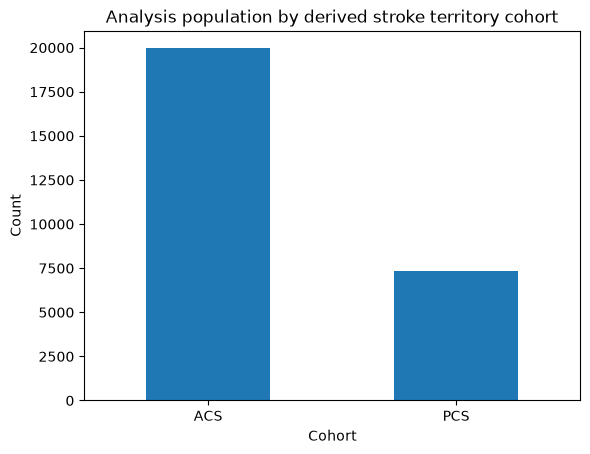

### Numeric variables before preprocessing

,variable,n_observed,n_missing,missing_rate,mean,std,min,q1,median,q3,max
0,age,27308,0,0.00%,71.70,13.62,20.00,63.00,74.00,82.00,105.00
1,nihss_24h,27308,0,0.00%,4.05,5.64,0.00,0.00,2.00,5.00,41.00
2,nihss_adm_score,27238,70,0.26%,5.90,6.39,0.00,1.00,4.00,8.00,41.00


### Categorical variables before preprocessing

,variable,level,level_label,count,percent_observed,n_missing,missing_rate
0,biol_sex,1,male,15979,58.5%,0,0.00%
1,biol_sex,2,female,11329,41.5%,0,0.00%
2,acute_treat_ivt,0,no,19360,71.1%,65,0.24%
3,acute_treat_ivt,1,yes,7883,28.9%,65,0.24%
4,acute_treat_evt,0,no,22276,81.8%,73,0.27%
5,acute_treat_evt,1,yes,4959,18.2%,73,0.27%
6,clinical_sdr,2,PACS partial anterior circulation syndrome,15137,55.4%,0,0.00%
7,clinical_sdr,4,POCS posterior circulation syndrome,7356,26.9%,0,0.00%
8,clinical_sdr,1,TACS total anterior circulation syndrome,4815,17.6%,0,0.00%
9,event_type,1,Ischemic stroke,27308,100.0%,0,0.00%


In [46]:
quality_summary = quality_pipeline.describe()

quality_numeric_df = numeric_describe_df(
    quality_summary,
    variables=[age, nihss_24h, nihss_adm],
)
quality_categorical_df = categorical_describe_df(
    quality_summary,
    variables=[sex, ivt, evt, clinical_sdr, event_type, good_outcome],
)

clinical_counts = quality_categorical_df[quality_categorical_df["variable"] == clinical_sdr.code]
clinical_counts_by_level = {
    str(row.level): float(row.count) for row in clinical_counts.itertuples(index=False)
}
cohort_counts_df = pd.DataFrame(
    [
        {
            "level": "ACS",
            "source_codes": "clinical_sdr 1 + 2",
            "count": clinical_counts_by_level.get("1", 0.0) + clinical_counts_by_level.get("2", 0.0),
        },
        {
            "level": "PCS",
            "source_codes": "clinical_sdr 4",
            "count": clinical_counts_by_level.get("4", 0.0),
        },
    ]
)
cohort_counts_df["percent"] = 100.0 * cohort_counts_df["count"] / cohort_counts_df["count"].sum()

analysis_n = int(cohort_counts_df["count"].sum())

display(Markdown(f"### Analysis population size: {analysis_n:,} records"))
display(Markdown("### Derived ACS/PCS cohort counts from raw `clinical_sdr` aggregate counts"))
display(
    cohort_counts_df.style.format(
        {"count": "{:.0f}", "percent": "{:.1f}%"},
        na_rep="-",
    )
)

ax = cohort_counts_df.plot(kind="bar", x="level", y="count", legend=False)
ax.set_title("Analysis population by derived stroke territory cohort")
ax.set_xlabel("Cohort")
ax.set_ylabel("Count")
plt.xticks(rotation=0)
plt.show()

display(Markdown("### Numeric variables before preprocessing"))
display(
    quality_numeric_df.style.format(
        {
            "n_observed": "{:.0f}",
            "n_missing": "{:.0f}",
            "missing_rate": "{:.2%}",
            "mean": "{:.2f}",
            "std": "{:.2f}",
            "min": "{:.2f}",
            "q1": "{:.2f}",
            "median": "{:.2f}",
            "q3": "{:.2f}",
            "max": "{:.2f}",
        },
        na_rep="-",
    )
)

display(Markdown("### Categorical variables before preprocessing"))
display(
    quality_categorical_df.style.format(
        {
            "count": "{:.0f}",
            "percent_observed": "{:.1f}%",
            "n_missing": "{:.0f}",
            "missing_rate": "{:.2%}",
        },
        na_rep="-",
    )
)

In [47]:
acs_quality_pipeline = mip.Pipeline(
    analysis_set=analysis_set,
    filters=population_filters & F(clinical_sdr).isin(["1", "2"]),
    new_columns=[stroke_territory_creator],
)
pcs_quality_pipeline = mip.Pipeline(
    analysis_set=analysis_set,
    filters=population_filters & (F(clinical_sdr) == "4"),
    new_columns=[stroke_territory_creator],
)

acs_quality_summary = acs_quality_pipeline.describe()
pcs_quality_summary = pcs_quality_pipeline.describe()

quality_numeric_by_cohort_df = pd.concat(
    [
        numeric_describe_df(acs_quality_summary, [age, nihss_24h, nihss_adm], cohort="ACS"),
        numeric_describe_df(pcs_quality_summary, [age, nihss_24h, nihss_adm], cohort="PCS"),
    ],
    ignore_index=True,
)

quality_categorical_by_cohort_df = pd.concat(
    [
        categorical_describe_df(acs_quality_summary, [sex, ivt, evt, good_outcome], cohort="ACS"),
        categorical_describe_df(pcs_quality_summary, [sex, ivt, evt, good_outcome], cohort="PCS"),
    ],
    ignore_index=True,
)

display(Markdown("### Numeric summaries by ACS/PCS before preprocessing"))
display(
    quality_numeric_by_cohort_df.style.format(
        {
            "n_observed": "{:.0f}",
            "n_missing": "{:.0f}",
            "missing_rate": "{:.2%}",
            "mean": "{:.2f}",
            "std": "{:.2f}",
            "min": "{:.2f}",
            "q1": "{:.2f}",
            "median": "{:.2f}",
            "q3": "{:.2f}",
            "max": "{:.2f}",
        },
        na_rep="-",
    )
)

display(Markdown("### Categorical summaries by ACS/PCS before preprocessing"))
display(
    quality_categorical_by_cohort_df.style.format(
        {
            "count": "{:.0f}",
            "percent_observed": "{:.1f}%",
            "n_missing": "{:.0f}",
            "missing_rate": "{:.2%}",
        },
        na_rep="-",
    )
)

### Numeric summaries by ACS/PCS before preprocessing

,cohort,variable,n_observed,n_missing,missing_rate,mean,std,min,q1,median,q3,max
0,ACS,age,19952,0,0.00%,72.65,13.24,20.00,65.00,75.00,83.00,105.00
1,ACS,nihss_24h,19952,0,0.00%,4.74,6.02,0.00,1.00,2.00,6.00,41.00
2,ACS,nihss_adm_score,19914,38,0.19%,6.88,6.60,0.00,2.00,5.00,10.00,41.00
3,PCS,age,7356,0,0.00%,69.10,14.28,20.00,60.00,72.00,80.00,100.00
4,PCS,nihss_24h,7356,0,0.00%,2.18,3.91,0.00,0.00,1.00,3.00,41.00
5,PCS,nihss_adm_score,7324,32,0.44%,3.21,4.87,0.00,1.00,2.00,4.00,41.00


### Categorical summaries by ACS/PCS before preprocessing

,cohort,variable,level,level_label,count,percent_observed,n_missing,missing_rate
0,ACS,biol_sex,1,male,11337,56.8%,0,0.00%
1,ACS,biol_sex,2,female,8615,43.2%,0,0.00%
2,ACS,acute_treat_ivt,0,no,13360,67.1%,47,0.24%
3,ACS,acute_treat_ivt,1,yes,6545,32.9%,47,0.24%
4,ACS,acute_treat_evt,0,no,15344,77.1%,53,0.27%
5,ACS,acute_treat_evt,1,yes,4555,22.9%,53,0.27%
6,ACS,fu_3m_mrs_good,1,yes,13384,67.1%,0,0.00%
7,ACS,fu_3m_mrs_good,0,no,6568,32.9%,0,0.00%
8,PCS,biol_sex,1,male,4642,63.1%,0,0.00%
9,PCS,biol_sex,2,female,2714,36.9%,0,0.00%


## 5. Prepare the analysis

The raw aggregate summaries above show small missingness in admission NIHSS, IVT, and EVT, and high-end values in NIHSS variables. The formal statistical pipeline uses backend preprocessing:

- Median imputation for numerical covariates `age`, `nihss_24h`, and `nihss_adm_score`.
- Most-frequent imputation for categorical covariates `biol_sex`, `acute_treat_ivt`, `acute_treat_evt`, and `fu_3m_mrs_good`.
- IQR winsorization with 1.5-fold fences for `age`, `nihss_24h`, and `nihss_adm_score`, both tails.
- The ACS/PCS cohort is created by backend filter rules from `clinical_sdr`.

Age and NIHSS remain clinically meaningful continuous variables after winsorization. The derived ACS/PCS cohort is clinically useful because it contrasts anterior and posterior circulation presentations while keeping the definition reproducible from verified metadata codes.

In [48]:
missing_handler = MissingValuesHandler(
    strategies={
        age: "median",
        nihss_24h: "median",
        nihss_adm: "median",
        sex: "most_frequent",
        ivt: "most_frequent",
        evt: "most_frequent",
        good_outcome: "most_frequent",
    }
)

outlier_handler = OutlierWinsorizer(
    strategies={
        age: "iqr",
        nihss_24h: "iqr",
        nihss_adm: "iqr",
    },
    tails={
        age: "both",
        nihss_24h: "both",
        nihss_adm: "both",
    },
    folds={
        age: 1.5,
        nihss_24h: 1.5,
        nihss_adm: 1.5,
    },
)

analysis_pipeline = mip.Pipeline(
    analysis_set=analysis_set,
    filters=population_filters,
    handle_missing=missing_handler,
    outlier_handling=outlier_handler,
    new_columns=[stroke_territory_creator],
)

prepared_summary = analysis_pipeline.describe()
prepared_numeric_df = numeric_describe_df(prepared_summary, [age, nihss_24h, nihss_adm])
prepared_categorical_df = categorical_describe_df(prepared_summary, [sex, ivt, evt, clinical_sdr, event_type, good_outcome])

display(Markdown("### Formal analysis pipeline"))
display(analysis_pipeline.explain())

display(Markdown("### Numeric variables after backend preprocessing"))
display(
    prepared_numeric_df.style.format(
        {
            "n_observed": "{:.0f}",
            "n_missing": "{:.0f}",
            "missing_rate": "{:.2%}",
            "mean": "{:.2f}",
            "std": "{:.2f}",
            "min": "{:.2f}",
            "q1": "{:.2f}",
            "median": "{:.2f}",
            "q3": "{:.2f}",
            "max": "{:.2f}",
        },
        na_rep="-",
    )
)

display(Markdown("### Categorical variables after backend preprocessing"))
display(
    prepared_categorical_df.style.format(
        {
            "count": "{:.0f}",
            "percent_observed": "{:.1f}%",
            "n_missing": "{:.0f}",
            "missing_rate": "{:.2%}",
        },
        na_rep="-",
    )
)

### Formal analysis pipeline

{'analysis_set': {'data_model': 'Stroke:3.7',
  'datasets': ['SSR'],
  'variables': ['age',
   'nihss_24h',
   'nihss_adm_score',
   'biol_sex',
   'acute_treat_ivt',
   'acute_treat_evt',
   'clinical_sdr',
   'event_type',
   'fu_3m_mrs_good']},
 'filters': {'condition': 'AND',
  'rules': [{'condition': 'AND',
    'rules': [{'condition': 'AND',
      'rules': [{'condition': 'AND',
        'rules': [{'condition': 'AND',
          'rules': [{'id': 'event_type',
            'field': 'event_type',
            'operator': 'equal',
            'value': '1',
            'type': 'string'},
           {'id': 'clinical_sdr',
            'field': 'clinical_sdr',
            'operator': 'in',
            'value': ['1', '2', '4'],
            'type': 'string'}]},
         {'id': 'age',
          'field': 'age',
          'operator': 'is_not_null',
          'value': None,
          'type': 'string'}]},
       {'id': 'nihss_24h',
        'field': 'nihss_24h',
        'operator': 'is_not_null',
   

### Numeric variables after backend preprocessing

,variable,n_observed,n_missing,missing_rate,mean,std,min,q1,median,q3,max
0,age,27308,0,0.00%,71.78,13.36,34.50,63.00,74.00,82.00,105.00
1,nihss_24h,27308,0,0.00%,3.51,4.03,0.00,0.00,2.00,5.00,12.50
2,nihss_adm_score,27308,0,0.00%,5.62,5.59,0.00,1.00,4.00,8.00,18.50


### Categorical variables after backend preprocessing

,variable,level,level_label,count,percent_observed,n_missing,missing_rate
0,biol_sex,1,male,15979,58.5%,0,0.00%
1,biol_sex,2,female,11329,41.5%,0,0.00%
2,acute_treat_ivt,0,no,19425,71.1%,0,0.00%
3,acute_treat_ivt,1,yes,7883,28.9%,0,0.00%
4,acute_treat_evt,0,no,22349,81.8%,0,0.00%
5,acute_treat_evt,1,yes,4959,18.2%,0,0.00%
6,clinical_sdr,2,PACS partial anterior circulation syndrome,15137,55.4%,0,0.00%
7,clinical_sdr,4,POCS posterior circulation syndrome,7356,26.9%,0,0.00%
8,clinical_sdr,1,TACS total anterior circulation syndrome,4815,17.6%,0,0.00%
9,event_type,1,Ischemic stroke,27308,100.0%,0,0.00%


## 6. Statistical procedures

The backend exposes several statistical procedures. This report uses procedures that match the research question and variable types:

- Independent t-tests compare continuous variables between `ACS` and `PCS`.
- Chi-square tests evaluate categorical associations between `ACS/PCS` and sex, acute treatments, and good 3-month outcome.
- Logistic regression models the binary outcome `fu_3m_mrs_good`, with `"1"` as the positive class, adjusting for clinically relevant covariates.

Pearson correlation is available but is not used for the main question because the primary outcome and several predictors are categorical.

### Independent t-tests

,comparison,t_stat,df,p_value,p_value_fmt,significance,mean_diff_ACS_minus_PCS,ci_lower,ci_upper,cohens_d
0,Age: ACS vs PCS,19.17,27306,0,<0.001,statistically significant,3.47,3.12,3.83,0.26
1,24h NIHSS: ACS vs PCS,38.90,27306,0,<0.001,statistically significant,2.08,1.98,2.19,0.53


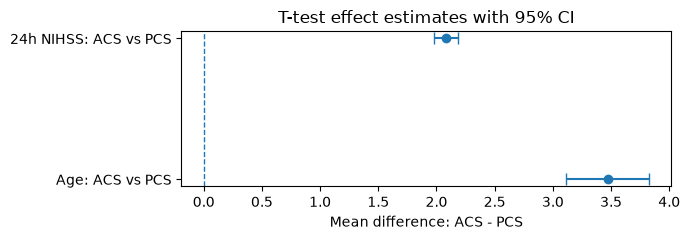

- Age: ACS vs PCS: mean difference ACS - PCS = 3.47 (95% CI 3.12 to 3.83), p=<0.001; this is statistically significant and the mean is higher in ACS.
- 24h NIHSS: ACS vs PCS: mean difference ACS - PCS = 2.08 (95% CI 1.98 to 2.19), p=<0.001; this is statistically significant and the mean is higher in ACS.

In [49]:
t_test_results = {
    "Age: ACS vs PCS": analysis_pipeline.t_test(
        variable=age,
        group_by=stroke_territory_cohort,
        group_a="ACS",
        group_b="PCS",
    ),
    "24h NIHSS: ACS vs PCS": analysis_pipeline.t_test(
        variable=nihss_24h,
        group_by=stroke_territory_cohort,
        group_a="ACS",
        group_b="PCS",
    ),
}

ttest_results_df = t_test_df(t_test_results)

display(Markdown("### Independent t-tests"))
display(
    ttest_results_df.style.format(
        {
            "t_stat": "{:.2f}",
            "df": "{:.0f}",
            "p_value": "{:.4g}",
            "mean_diff_ACS_minus_PCS": "{:.2f}",
            "ci_lower": "{:.2f}",
            "ci_upper": "{:.2f}",
            "cohens_d": "{:.2f}",
        },
        na_rep="-",
    )
)

plot_df = ttest_results_df.dropna(subset=["mean_diff_ACS_minus_PCS", "ci_lower", "ci_upper"]).copy()
y_pos = np.arange(len(plot_df))
fig, ax = plt.subplots(figsize=(7, max(2.5, 0.6 * len(plot_df))))
ax.errorbar(
    plot_df["mean_diff_ACS_minus_PCS"],
    y_pos,
    xerr=[
        plot_df["mean_diff_ACS_minus_PCS"] - plot_df["ci_lower"],
        plot_df["ci_upper"] - plot_df["mean_diff_ACS_minus_PCS"],
    ],
    fmt="o",
    capsize=4,
)
ax.axvline(0, linestyle="--", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["comparison"])
ax.set_xlabel("Mean difference: ACS - PCS")
ax.set_title("T-test effect estimates with 95% CI")
plt.tight_layout()
plt.show()

notes = []
for row in ttest_results_df.itertuples(index=False):
    direction = "higher in ACS" if row.mean_diff_ACS_minus_PCS > 0 else "lower in ACS"
    notes.append(
        f"- {row.comparison}: mean difference ACS - PCS = {row.mean_diff_ACS_minus_PCS:.2f} "
        f"(95% CI {row.ci_lower:.2f} to {row.ci_upper:.2f}), p={row.p_value_fmt}; "
        f"this is {row.significance} and the mean is {direction}."
    )

display(Markdown("\n".join(notes)))

In [50]:
chi_square_results = {
    "ACS/PCS vs sex": analysis_pipeline.chi_square_test(
        x=stroke_territory_cohort,
        y=sex,
    ),
    "ACS/PCS vs IVT": analysis_pipeline.chi_square_test(
        x=stroke_territory_cohort,
        y=ivt,
    ),
    "ACS/PCS vs EVT": analysis_pipeline.chi_square_test(
        x=stroke_territory_cohort,
        y=evt,
    ),
    "ACS/PCS vs good 3m mRS": analysis_pipeline.chi_square_test(
        x=stroke_territory_cohort,
        y=good_outcome,
    ),
}

chi_square_results_df = chi_square_df(chi_square_results)

display(Markdown("### Chi-square tests"))
display(
    chi_square_results_df.style.format(
        {
            "chi2": "{:.2f}",
            "dof": "{:.0f}",
            "p_value": "{:.4g}",
        },
        na_rep="-",
    )
)

chi_notes = []
for row in chi_square_results_df.itertuples(index=False):
    chi_notes.append(
        f"- {row.comparison}: chi-square p={row.p_value_fmt}; "
        f"the association is {row.significance} at alpha={ALPHA}."
    )

display(Markdown("\n".join(chi_notes)))

### Chi-square tests

,comparison,chi2,dof,p_value,p_value_fmt,significance
0,ACS/PCS vs sex,87.16,1,1.002e-20,<0.001,statistically significant
1,ACS/PCS vs IVT,558.32,1,1.954e-123,<0.001,statistically significant
2,ACS/PCS vs EVT,1085.88,1,3.873e-238,<0.001,statistically significant
3,ACS/PCS vs good 3m mRS,541.46,1,9.09e-120,<0.001,statistically significant


- ACS/PCS vs sex: chi-square p=<0.001; the association is statistically significant at alpha=0.05.
- ACS/PCS vs IVT: chi-square p=<0.001; the association is statistically significant at alpha=0.05.
- ACS/PCS vs EVT: chi-square p=<0.001; the association is statistically significant at alpha=0.05.
- ACS/PCS vs good 3m mRS: chi-square p=<0.001; the association is statistically significant at alpha=0.05.

### Adjusted logistic regression for good 3-month mRS outcome

,label,coef,stderr,odds_ratio,or_lower_ci,or_upper_ci,z_score,p_value,significance
0,Intercept,7.059,0.129,1162.86,903.51,1496.65,54.82,0,statistically significant
1,Sex: female,-0.170,0.035,0.84,0.79,0.90,-4.89,1.024e-06,statistically significant
2,IVT: yes,0.479,0.040,1.62,1.49,1.75,11.84,2.288e-32,statistically significant
3,EVT: yes,0.288,0.050,1.33,1.21,1.47,5.71,1.135e-08,statistically significant
4,PCS vs ACS,-0.010,0.042,0.99,0.91,1.07,-0.24,0.812,not statistically significant
5,Age,-0.063,0.002,0.94,0.94,0.94,-39.52,0,statistically significant
6,24h score,-0.322,0.006,0.72,0.72,0.73,-53.74,0,statistically significant
7,Admission score,-0.045,0.005,0.96,0.95,0.96,-9.71,2.716e-22,statistically significant


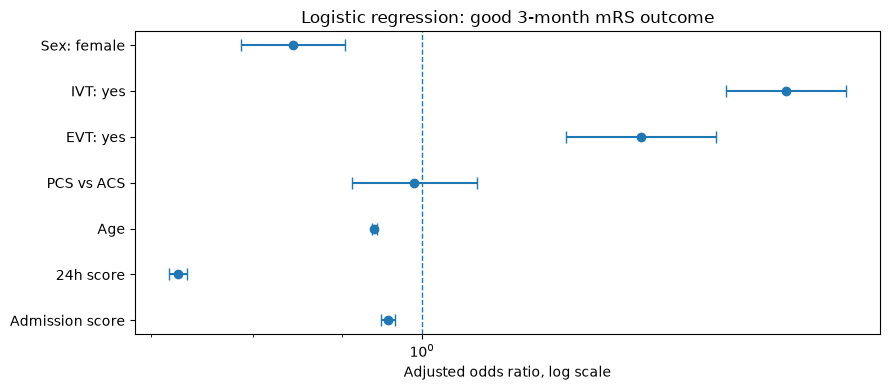

Adjusted PCS vs ACS odds ratio = 0.99 (95% CI 0.91 to 1.07), p=0.812. This adjusted association is not statistically significant; the point estimate suggests lower odds of good 3-month mRS for PCS, but the statistical interpretation should follow the confidence interval and p-value.

In [51]:
logistic_regression_result = analysis_pipeline.logistic_regression(
    x=[
        age,
        nihss_24h,
        nihss_adm,
        sex,
        ivt,
        evt,
        stroke_territory_cohort,
    ],
    y=good_outcome,
    positive_class="1",
)

logreg_payload = logistic_regression_result.summary()
logreg_variables_by_code = {
    age.code: age,
    nihss_24h.code: nihss_24h,
    nihss_adm.code: nihss_adm,
    sex.code: sex,
    ivt.code: ivt,
    evt.code: evt,
    stroke_territory_cohort.code: stroke_territory_cohort,
}

logreg_df = logistic_result_to_dataframe(logistic_regression_result)
logreg_df["label"] = logreg_df["term"].apply(
    lambda term: logistic_term_label(term, logreg_variables_by_code)
)
logreg_df["or_95_ci"] = logreg_df.apply(
    lambda row: f"{row['odds_ratio']:.2f} ({row['or_lower_ci']:.2f}, {row['or_upper_ci']:.2f})",
    axis=1,
)

display(Markdown("### Adjusted logistic regression for good 3-month mRS outcome"))
display(
    logreg_df[
        [
            "label",
            "coef",
            "stderr",
            "odds_ratio",
            "or_lower_ci",
            "or_upper_ci",
            "z_score",
            "p_value",
            "significance",
        ]
    ].style.format(
        {
            "coef": "{:.3f}",
            "stderr": "{:.3f}",
            "odds_ratio": "{:.2f}",
            "or_lower_ci": "{:.2f}",
            "or_upper_ci": "{:.2f}",
            "z_score": "{:.2f}",
            "p_value": "{:.4g}",
        },
        na_rep="-",
    )
)

forest_df = logreg_df[logreg_df["term"] != "Intercept"].iloc[::-1].copy()
y_pos = np.arange(len(forest_df))
fig, ax = plt.subplots(figsize=(9, max(4, 0.55 * len(forest_df))))
ax.errorbar(
    forest_df["odds_ratio"],
    y_pos,
    xerr=[
        forest_df["odds_ratio"] - forest_df["or_lower_ci"],
        forest_df["or_upper_ci"] - forest_df["odds_ratio"],
    ],
    fmt="o",
    capsize=4,
)
ax.axvline(1, linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_yticks(y_pos)
ax.set_yticklabels(forest_df["label"])
ax.set_xlabel("Adjusted odds ratio, log scale")
ax.set_title("Logistic regression: good 3-month mRS outcome")
plt.tight_layout()
plt.show()

pcs_row = logreg_df[logreg_df["term"] == "stroke_territory_cohort[PCS]"].iloc[0]
pcs_direction = "higher" if pcs_row.odds_ratio > 1 else "lower"
pcs_text = (
    f"Adjusted PCS vs ACS odds ratio = {pcs_row.odds_ratio:.2f} "
    f"(95% CI {pcs_row.or_lower_ci:.2f} to {pcs_row.or_upper_ci:.2f}), "
    f"p={pcs_row.p_value_fmt}. This adjusted association is {pcs_row.significance}; "
    f"the point estimate suggests {pcs_direction} odds of good 3-month mRS for PCS, "
    "but the statistical interpretation should follow the confidence interval and p-value."
)

display(Markdown(pcs_text))

In [52]:
model_summary = logreg_payload["summary"]
fit_df = pd.DataFrame(
    {
        "metric": [
            "N observations",
            "df model",
            "df residual",
            "Cox-Snell pseudo R^2",
            "McFadden pseudo R^2",
            "Log-likelihood null",
            "Log-likelihood model",
            "AIC",
            "BIC",
        ],
        "value": [
            model_summary.get("n_obs"),
            model_summary.get("df_model"),
            model_summary.get("df_resid"),
            model_summary.get("r_squared_cs"),
            model_summary.get("r_squared_mcf"),
            model_summary.get("ll0"),
            model_summary.get("ll"),
            model_summary.get("aic"),
            model_summary.get("bic"),
        ],
    }
)

display(Markdown("### Logistic regression model fit"))
display(fit_df.style.format({"value": "{:.3f}"}, na_rep="-"))

feature_schema = logistic_regression_result.feature_schema()
display(Markdown("### Requirements for local reuse of fitted logistic output"))
display(feature_schema)

try:
    sklearn_model = logistic_regression_result.to_sklearn()
    local_reuse_note = (
        "The fitted model can be materialized locally with `to_sklearn()`. "
        "Any local prediction dataframe must already be preprocessed and must contain exactly "
        "the feature columns listed in `feature_schema()` in the required order."
    )
except Exception as exc:
    sklearn_model = None
    local_reuse_note = (
        "The backend result did not materialize as a local sklearn object in this run. "
        f"Reason: {type(exc).__name__}: {exc}"
    )

display(Markdown(local_reuse_note))

### Logistic regression model fit

,metric,value
0,N observations,27308.000
1,df model,7.000
2,df residual,27300.000
3,Cox-Snell pseudo R^2,0.330
4,McFadden pseudo R^2,0.333
5,Log-likelihood null,-16452.217
6,Log-likelihood model,-10977.810
7,AIC,21971.621
8,BIC,22037.340


### Requirements for local reuse of fitted logistic output

{'feature_names': ['biol_sex[2]',
  'acute_treat_ivt[1]',
  'acute_treat_evt[1]',
  'stroke_territory_cohort[PCS]',
  'age',
  'nihss_24h',
  'nihss_adm_score'],
 'input_type': 'pandas.DataFrame',
 'requires_preprocessed_input': True,
 'rule': 'Columns must match sklearn_model.feature_names_in_ exactly and in order.'}

The fitted model can be materialized locally with `to_sklearn()`. Any local prediction dataframe must already be preprocessed and must contain exactly the feature columns listed in `feature_schema()` in the required order.

## 7. Interpretation guardrails and limitations

The statistical results should be read as associations in the selected SSR analysis population.

Important limitations:

- This is an observational federated analysis, not a randomized or causal design.
- ACS/PCS is derived from clinical syndrome codes, not directly from raw imaging-confirmed lesion maps.
- Very large sample sizes can make small differences statistically significant; clinical importance should be judged from effect sizes and confidence intervals, not p-values alone.
- Missing admission NIHSS, IVT, and EVT values are handled by backend imputation for modeling; this may not remove missing-data bias.
- IQR winsorization reduces the influence of extreme numeric values but can change means and regression estimates.
- Only backend-approved aggregate summaries and fitted model outputs are used; no raw record audit is performed in this notebook.

In [53]:
significant_t = ttest_results_df[ttest_results_df["p_value"] < ALPHA]["comparison"].tolist()
significant_chi = chi_square_results_df[chi_square_results_df["p_value"] < ALPHA]["comparison"].tolist()
significant_logreg = logreg_df[(logreg_df["term"] != "Intercept") & (logreg_df["p_value"] < ALPHA)]["label"].tolist()

acs_count = cohort_counts_df.loc[cohort_counts_df["level"] == "ACS", "count"].iloc[0]
pcs_count = cohort_counts_df.loc[cohort_counts_df["level"] == "PCS", "count"].iloc[0]

summary_markdown = f"""
## Reproducibility summary

**Selected data resource:** `Stroke` data model version `3.7`.

**Selected dataset:** `SSR` (`SSR-even` and `SSR-odd` were discovered but not used for this report).

**Selected variables:** `{', '.join(required_variable_codes)}`.

**Derived variable:** `stroke_territory_cohort`, built with backend `CategoricalColumnCreator` from `clinical_sdr`: `ACS` = TACS/PACS (`1` or `2`), `PCS` = POCS (`4`).

**Analysis population:** ischemic stroke records with `event_type == "1"`, `clinical_sdr` in `1/2/4`, non-missing `age`, non-missing `nihss_24h`, known male/female `biol_sex`, and known binary `fu_3m_mrs_good`. The resulting cohort size is {analysis_n:,}: ACS {acs_count:,.0f}, PCS {pcs_count:,.0f}.

**Outcome definition:** `fu_3m_mrs_good`, where `1` means good 3-month mRS outcome and `0` means not good.

**Preprocessing choices:** median imputation for `age`, `nihss_24h`, and `nihss_adm_score`; most-frequent imputation for `biol_sex`, `acute_treat_ivt`, `acute_treat_evt`, and `fu_3m_mrs_good`; IQR winsorization with 1.5-fold fences for `age`, `nihss_24h`, and `nihss_adm_score`; ACS/PCS cohort creation by backend filter rules.

**Statistical procedures executed:** backend `describe`, independent `t_test`, `chi_square_test`, and `logistic_regression`.

**Statistical significance summary:** t-test associations significant at alpha={ALPHA}: {', '.join(significant_t) if significant_t else 'none'}. Chi-square associations significant at alpha={ALPHA}: {', '.join(significant_chi) if significant_chi else 'none'}. Adjusted logistic regression covariates significant at alpha={ALPHA}: {', '.join(significant_logreg) if significant_logreg else 'none'}.

**Main adjusted clinical interpretation:** PCS vs ACS has adjusted OR {pcs_row.odds_ratio:.2f} (95% CI {pcs_row.or_lower_ci:.2f} to {pcs_row.or_upper_ci:.2f}), p={pcs_row.p_value_fmt}; this is {pcs_row.significance}. The analysis supports association statements only, not causal claims.

**Local fitted-output reuse:** the logistic result exposes `feature_schema()` with feature names `{feature_schema.get('feature_names')}`. Local reuse requires a pandas dataframe that has already undergone equivalent preprocessing and whose columns exactly match this schema and order.
"""

display(Markdown(summary_markdown))


## Reproducibility summary

**Selected data resource:** `Stroke` data model version `3.7`.

**Selected dataset:** `SSR` (`SSR-even` and `SSR-odd` were discovered but not used for this report).

**Selected variables:** `age, nihss_24h, nihss_adm_score, biol_sex, acute_treat_ivt, acute_treat_evt, clinical_sdr, event_type, fu_3m_mrs_good`.

**Derived variable:** `stroke_territory_cohort`, built with backend `CategoricalColumnCreator` from `clinical_sdr`: `ACS` = TACS/PACS (`1` or `2`), `PCS` = POCS (`4`).

**Analysis population:** ischemic stroke records with `event_type == "1"`, `clinical_sdr` in `1/2/4`, non-missing `age`, non-missing `nihss_24h`, known male/female `biol_sex`, and known binary `fu_3m_mrs_good`. The resulting cohort size is 27,308: ACS 19,952, PCS 7,356.

**Outcome definition:** `fu_3m_mrs_good`, where `1` means good 3-month mRS outcome and `0` means not good.

**Preprocessing choices:** median imputation for `age`, `nihss_24h`, and `nihss_adm_score`; most-frequent imputation for `biol_sex`, `acute_treat_ivt`, `acute_treat_evt`, and `fu_3m_mrs_good`; IQR winsorization with 1.5-fold fences for `age`, `nihss_24h`, and `nihss_adm_score`; ACS/PCS cohort creation by backend filter rules.

**Statistical procedures executed:** backend `describe`, independent `t_test`, `chi_square_test`, and `logistic_regression`.

**Statistical significance summary:** t-test associations significant at alpha=0.05: Age: ACS vs PCS, 24h NIHSS: ACS vs PCS. Chi-square associations significant at alpha=0.05: ACS/PCS vs sex, ACS/PCS vs IVT, ACS/PCS vs EVT, ACS/PCS vs good 3m mRS. Adjusted logistic regression covariates significant at alpha=0.05: Sex: female, IVT: yes, EVT: yes, Age, 24h score, Admission score.

**Main adjusted clinical interpretation:** PCS vs ACS has adjusted OR 0.99 (95% CI 0.91 to 1.07), p=0.812; this is not statistically significant. The analysis supports association statements only, not causal claims.

**Local fitted-output reuse:** the logistic result exposes `feature_schema()` with feature names `['biol_sex[2]', 'acute_treat_ivt[1]', 'acute_treat_evt[1]', 'stroke_territory_cohort[PCS]', 'age', 'nihss_24h', 'nihss_adm_score']`. Local reuse requires a pandas dataframe that has already undergone equivalent preprocessing and whose columns exactly match this schema and order.
